<a href="https://colab.research.google.com/github/cor1nnama/QuantSC-Stock-ETF-Research/blob/main/Lead_Lag_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lead–Lag Structure in US Equities**  
### Network Construction, Clustering, and Trading Signal Backtest

This notebook implements a prototype version of the lead–lag detection and clustering framework introduced in:

> Bennett, Cucuringu, Reinert (2022) — *Lead–lag detection and network clustering for multivariate time series*

The goal is to:
1. Detect directional relationships between stocks (who leads, who follows)
2. Represent these relationships as a directed network
3. Cluster stocks into leader/lagger groups
4. Construct a trading signal based on delayed information diffusion

---

### Pipeline

Our implementation follows:

1. Data cleaning and universe selection  
2. Construction of return time series  
3. Pairwise lead–lag estimation  
4. Directed network construction  
5. Spectral clustering of the network  
6. Signal construction and backtesting  

This notebook focuses on building a clean and interpretable prototype of this pipeline.

In [ ]:
#import necessary modules

import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sp
import statsmodels as sm
from matplotlib import pyplot as plt
from matplotlib import rcParams
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from patsy import dmatrix

In [ ]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_to_file = '/content/drive/MyDrive/USC/3. CLUBS/QUANT SC/S26 Single Stock ETF/Data/CRSP/CRSP_Daily_US_Common_Stock_Sample_2020_2025.csv.gz'

## Data Cleaning and Preprocessing

We begin with CRSP daily equity data.

Key challenges in raw financial data:
- duplicate observations per (date, stock)
- missing prices due to non-trading
- inconsistent formatting of numeric fields
- negative price conventions (CRSP bid/ask encoding)

---

### Steps

1. Convert all fields to proper numeric types  
2. Parse dates into `datetime` format  
3. Restrict to NYSE stocks (for consistency and liquidity)  
4. Compute dollar volume as a liquidity proxy  


In [ ]:
df = pd.read_csv(path_to_file, nrows=0)
print(df.columns.tolist())

['PERMNO', 'SecInfoStartDt', 'SecInfoEndDt', 'SecurityBegDt', 'SecurityEndDt', 'SecurityHdrFlg', 'HdrCUSIP', 'HdrCUSIP9', 'CUSIP', 'CUSIP9', 'PrimaryExch', 'ConditionalType', 'ExchangeTier', 'TradingStatusFlg', 'SecurityNm', 'ShareClass', 'USIncFlg', 'IssuerType', 'SecurityType', 'SecuritySubType', 'ShareType', 'SecurityActiveFlg', 'DelActionType', 'DelStatusType', 'DelReasonType', 'DelPaymentType', 'Ticker', 'TradingSymbol', 'PERMCO', 'SICCD', 'NAICS', 'ICBIndustry', 'NASDCompno', 'NASDIssuno', 'IssuerNm', 'YYYYMMDD', 'DlyCalDt', 'DlyDelFlg', 'DlyPrc', 'DlyPrcFlg', 'DlyCap', 'DlyCapFlg', 'DlyPrevPrc', 'DlyPrevPrcFlg', 'DlyPrevDt', 'DlyPrevCap', 'DlyPrevCapFlg', 'DlyRet', 'DlyRetx', 'DlyRetI', 'DlyRetMissFlg', 'DlyRetDurFlg', 'DlyOrdDivAmt', 'DlyNonOrdDivAmt', 'DlyFacPrc', 'DlyDistRetFlg', 'DlyVol', 'DlyClose', 'DlyLow', 'DlyHigh', 'DlyBid', 'DlyAsk', 'DlyOpen', 'DlyNumTrd', 'DlyMMCnt', 'DlyPrcVol', 'ShrStartDt', 'ShrEndDt', 'ShrOut', 'ShrSource', 'ShrFacType', 'ShrAdrFlg', 'DisExDt', 

In [ ]:
cols_to_keep = [
    'PERMNO', 'DlyCalDt', 'DlyRet', 'DlyPrc', 'DlyVol',
    'DlyCap', 'SICCD', 'Ticker', 'PrimaryExch'
]

df = pd.read_csv(path_to_file, usecols=cols_to_keep)
df.shape

(6030694, 9)

In [ ]:
# Parse dates
df['DlyCalDt'] = pd.to_datetime(df['DlyCalDt'], errors='coerce')

# NYSE only
df = df[df['PrimaryExch'] == 'N']
df.shape

(1967300, 9)

In [ ]:
# Clean numerics
df['DlyRet'] = pd.to_numeric(df['DlyRet'], errors='coerce')
df['DlyPrc'] = pd.to_numeric(df['DlyPrc'], errors='coerce').abs()
df['DlyVol'] = pd.to_numeric(df['DlyVol'], errors='coerce')
df['DlyCap'] = pd.to_numeric(df['DlyCap'], errors='coerce')
df['DlyDolVol'] = df['DlyPrc'] * df['DlyVol']

## Universe Selection

We restrict the dataset to a liquid subset of stocks.

---

### Filtering Criteria

We compute per-stock statistics:
- average dollar volume  
- average market capitalization  
- number of trading days  

Then apply:
- minimum trading history (~2.5 years)
- top 500 stocks by average dollar volume  

---

### Motivation

Lead–lag effects are stronger and more reliable in:
- highly traded securities  
- stocks with continuous price histories  

Illiquid stocks introduce:
- artificial delays (non-synchronous trading)
- spurious correlations  

This step ensures a stable and realistic trading universe.

In [ ]:
# Per-stock stats and filtering

stock_stats = df.groupby('PERMNO').agg(
    avg_dollar_vol=('DlyDolVol', 'mean'),
    avg_market_cap=('DlyCap', 'mean'),
    n_trading_days=('DlyPrc', 'count'),
    ticker=('Ticker', 'last'),
    siccd=('SICCD', 'last')
)

# At least ~2.5 years of daily observations
stock_stats = stock_stats[stock_stats['n_trading_days'] >= 625].copy()

# Top 500 by average dollar volume
stock_stats = stock_stats.nlargest(500, 'avg_dollar_vol').copy()

keep_permnos = stock_stats.index
df = df[df['PERMNO'].isin(keep_permnos)].copy()

print(f'Universe size after filtering: {len(keep_permnos)}')
stock_stats.head(10)

Universe size after filtering: 500


,avg_dollar_vol,avg_market_cap,n_trading_days,ticker,siccd
PERMNO,,,,,
19561,2.293409e+09,1.216271e+08,1508,BA,3721
47896,1.947234e+09,4.926049e+08,1508,JPM,6021
92655,1.939552e+09,4.082429e+08,1508,UNH,6324
92611,1.805605e+09,4.109714e+08,1508,V,7389
11850,1.731240e+09,3.697817e+08,1508,XOM,1311
59408,1.698442e+09,2.954787e+08,1508,BAC,6029
17778,1.653792e+09,3.025477e+08,1508,BRK,6331
90215,1.587027e+09,2.202298e+08,1508,CRM,7372
50876,1.573388e+09,4.407451e+08,1508,LLY,2834


## Price Matrix Construction and Return Computation

We convert the dataset into a matrix representation:

- rows = dates  
- columns = stocks  
- values = prices  

---

### Key Steps

1. Remove duplicate (date, stock) observations  
2. Pivot into a price matrix  
3. Forward-fill missing prices  
4. Compute log returns  

---

### Why Log Returns?

We define:

$$
r_t^i = \log P_t^i - \log P_{t-1}^i
$$

Log returns are preferred because:
- they are approximately stationary  
- they are additive over time  
- they simplify correlation-based analysis  

---

### Forward-Filling

We forward-fill missing prices to:
- maintain a dense panel  
- avoid losing large portions of data  

This implicitly assumes:
- no trade = no price update  

which is standard in daily equity data.

In [ ]:
# Sort and deduplicate ONCE
df = df.sort_values(['PERMNO', 'DlyCalDt']).copy()
dup_count = df.duplicated(subset=['DlyCalDt', 'PERMNO']).sum()
print('Duplicate (date, PERMNO) rows before drop:', int(dup_count))

df = df.drop_duplicates(subset=['DlyCalDt', 'PERMNO'], keep='last').copy()

# Pivot PRICE matrix, not returns
px = df.pivot(index='DlyCalDt', columns='PERMNO', values='DlyPrc').sort_index()

# Forward-fill remaining missing prices
px = px.ffill()

# Compute log returns from prices
log_px = np.log(px)
ret = log_px.diff()

# Remove rows that are entirely missing
ret = ret.dropna(how='all')

# Optional clipping for broken points
ret = ret.clip(-0.50, 0.50)

print('Price matrix shape:', px.shape)
print('Return matrix shape:', ret.shape)
print('Average missing fraction in returns matrix:', ret.isna().mean().mean())
ret.iloc[:5, :5]

Duplicate (date, PERMNO) rows before drop: 93
Price matrix shape: (1508, 500)
Return matrix shape: (1507, 500)
Average missing fraction in returns matrix: 0.02275514266755143


PERMNO,10104,10516,10933,11308,11404
DlyCalDt,,,,,
2020-01-03,-0.003528,-0.001954,0.005370,-0.005470,-0.002592
2020-01-06,0.005195,-0.007853,-0.000732,-0.000366,-0.003277
2020-01-07,0.002218,-0.012119,-0.000388,-0.007712,-0.007613
2020-01-08,-0.000554,-0.011146,-0.006416,0.001842,-0.008017
2020-01-09,0.004608,-0.010365,0.011352,0.018051,-0.001035


In [ ]:
summary = pd.DataFrame({
    'missing_frac': ret.isna().mean(),
    'vol_daily': ret.std(),
    'mean_daily': ret.mean()
}).join(stock_stats[['ticker', 'avg_dollar_vol', 'avg_market_cap']], how='left')

summary.sort_values('missing_frac').head(10)


,missing_frac,vol_daily,mean_daily,ticker,avg_dollar_vol,avg_market_cap
PERMNO,,,,,,
64282,0.0,0.037938,0.000092,BBWI,1.707318e+08,9.617092e+06
69796,0.0,0.018142,-0.000206,STZ,2.856999e+08,3.770785e+07
69649,0.0,0.023956,0.000379,RJF,1.243587e+08,2.171123e+07
69032,0.0,0.021894,0.000814,MS,7.507106e+08,1.558943e+08
66800,0.0,0.024129,0.000333,AIG,2.708637e+08,4.269590e+07
66376,0.0,0.019531,0.000419,WSO,9.076008e+07,1.119407e+07
66181,0.0,0.017853,0.000298,HD,1.239566e+09,3.315931e+08
66157,0.0,0.022951,-0.000069,USB,3.944745e+08,6.941197e+07
66093,0.0,0.017221,-0.000297,T,9.580866e+08,1.691834e+08


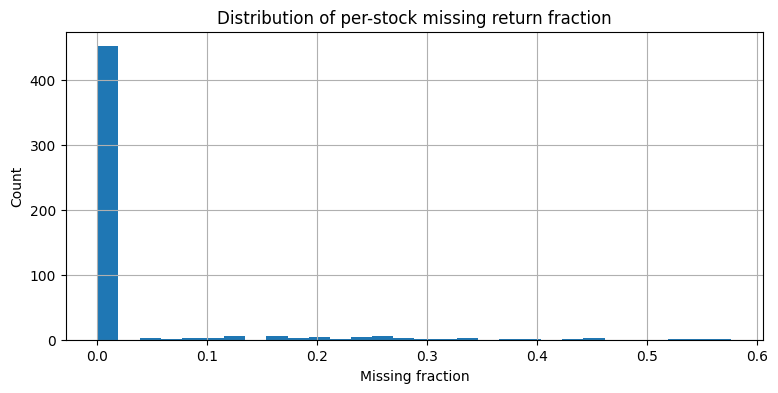

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
summary['missing_frac'].hist(bins=30, ax=ax)
ax.set_title('Distribution of per-stock missing return fraction')
ax.set_xlabel('Missing fraction')
ax.set_ylabel('Count')
plt.show()

## Lead–Lag Estimation

We estimate pairwise directional relationships between stocks.

---

### Definition

Stock \( $i$\) leads stock \( $j$ \) if:

$$
r_i(t-1) \text{ is more correlated with } r_j(t)
$$

than:

$$
r_i(t+1) \text{ is with } r_j(t)
$$

---

### Lead–Lag Score

We compute:

$$
S_{ij} = \text{corr}(r_i(t-1), r_j(t)) - \text{corr}(r_i(t), r_j(t-1))
$$

Interpretation:
- \( $S_{ij} > 0 $\): i leads j  
- \( $S_{ij} < 0 $\): j leads i  

---

### Properties

- The matrix \( $S$ \) is skew-symmetric:  
 $$
  S_{ij} = -S_{ji}
 $$

- Captures **directionality**, not just correlation

---

### Practical Considerations

We:
- remove columns with excessive missing data  
- drop zero-variance stocks  
- standardize returns  

These steps prevent numerical instability and spurious signals.

In [ ]:
def standardize_columns(X: np.ndarray) -> np.ndarray:
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd = np.where(sd == 0, np.nan, sd)
    return (X - mu) / sd


def compute_lead_lag_matrix_lag1(ret_window: pd.DataFrame,
                                 min_non_nan_frac: float = 0.90,
                                 min_obs: int = 20) -> pd.DataFrame:
    """
    Lag-1 lead-lag score:
        S_ij = corr(r_i(t-1), r_j(t)) - corr(r_i(t), r_j(t-1))
    """

    if ret_window.empty:
        raise ValueError("ret_window is empty")

    # 1) keep reasonably dense columns
    good_cols = ret_window.columns[ret_window.notna().mean() >= min_non_nan_frac]
    Xdf = ret_window[good_cols].copy()

    # 2) drop rows with any remaining NaNs
    Xdf = Xdf.dropna(axis=0, how='any')

    if Xdf.shape[0] < min_obs or Xdf.shape[1] < 2:
        raise ValueError("Not enough dense observations to compute lead-lag matrix")

    # 3) drop zero-variance columns BEFORE standardizing
    col_std = Xdf.std(axis=0, ddof=0)
    Xdf = Xdf.loc[:, col_std > 0]

    if Xdf.shape[1] < 2:
        raise ValueError("Too few non-constant columns after variance filter")

    X = Xdf.to_numpy(dtype=float)

    # 4) standardize safely
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    X = (X - mu) / sd

    # 5) lagged matrices
    X_lag = X[:-1]
    X_fwd = X[1:]

    if X_lag.shape[0] < 2:
        raise ValueError("Not enough rows after lagging")

    # 6) compute score
    c_plus = (X_lag.T @ X_fwd) / X_lag.shape[0]
    c_minus = (X_fwd.T @ X_lag) / X_fwd.shape[0]
    S = c_plus - c_minus

    # 7) enforce structure + remove numerical junk
    S = 0.5 * (S - S.T)
    np.fill_diagonal(S, 0.0)

    # 8) final finite check
    if not np.isfinite(S).all():
        bad = np.argwhere(~np.isfinite(S))
        raise ValueError(f"S contains non-finite values; first few bad indices: {bad[:10]}")

    return pd.DataFrame(S, index=Xdf.columns, columns=Xdf.columns)


def build_adjacency_from_S(S: pd.DataFrame) -> pd.DataFrame:
    A = np.maximum(S.to_numpy(), 0.0)
    return pd.DataFrame(A, index=S.index, columns=S.columns)


def cluster_leadingness(A: pd.DataFrame, clusters: pd.Series) -> pd.Series:
    '''
    Cluster leadingness = outflow - inflow
    '''
    cluster_ids = sorted(clusters.unique())
    scores = {}

    for c in cluster_ids:
        idx = clusters.index[clusters == c]
        outflow = A.loc[idx, :].to_numpy().sum()
        inflow = A.loc[:, idx].to_numpy().sum()
        scores[c] = outflow - inflow

    return pd.Series(scores).sort_values(ascending=False)


## Directed Network Construction

We convert the lead–lag matrix into a directed graph.

---

### Definition

$$
A_{ij} = \max(S_{ij}, 0)
$$

- Nodes = stocks  
- Edge \( $i \to j$ \) exists if i leads j  
- Edge weight = strength of lead–lag relationship  

---

### Interpretation

- High outflow → leader  
- High inflow → lagger  

This transforms a statistical problem into a **network problem**.

---

### Why This Step?

Working with a network allows us to:
- analyze global structure  
- detect clusters of leaders and followers  
- apply graph-based algorithms  

This is central to the paper’s methodology.

## Directed Network Clustering

We cluster stocks based on their lead–lag relationships.

---

### Goal

Partition stocks into groups such that:
- some clusters systematically lead others  
- others systematically lag  

---

### Method: Hermitian Spectral Clustering

We construct:

$$
H = i (A - A^T)
$$

This matrix is Hermitian, which allows:
- real eigenvalues  
- stable spectral decomposition  

---

### Procedure

1. Compute eigenvectors of \( H \)  
2. Embed nodes in low-dimensional space  
3. Apply k-means clustering  

---

### Why Not Standard Clustering?

Standard clustering:
- ignores directionality  

Hermitian method:
- explicitly captures **flow imbalance**  
- aligns with the paper’s framework  

---

### Output

Each stock is assigned to a cluster:
- some clusters = leaders  
- others = laggers  

In [ ]:
def hermitian_cluster(A: pd.DataFrame,
                      n_clusters: int = 10,
                      n_eigs: int | None = None,
                      random_state: int = 42):
    if n_eigs is None:
        n_eigs = n_clusters

    M = A.to_numpy(dtype=float)

    if not np.isfinite(M).all():
        bad = np.argwhere(~np.isfinite(M))
        raise ValueError(f"A contains non-finite values; first few bad indices: {bad[:10]}")

    H = 1j * (M - M.T)

    eigvals, eigvecs = np.linalg.eigh(H)
    order = np.argsort(np.abs(eigvals))[::-1][:n_eigs]

    V = eigvecs[:, order]
    embed = np.hstack([V.real, V.imag])

    # remove any all-constant embedding columns
    keep = np.nanstd(embed, axis=0) > 0
    embed = embed[:, keep]

    if embed.shape[1] == 0:
        raise ValueError("Embedding has no non-constant columns")

    if not np.isfinite(embed).all():
        bad = np.argwhere(~np.isfinite(embed))
        raise ValueError(f"Embedding contains non-finite values; first few bad indices: {bad[:10]}")

    km = KMeans(n_clusters=n_clusters, n_init=20, random_state=random_state)
    labels = km.fit_predict(embed)

    clusters = pd.Series(labels, index=A.index, name='cluster')
    eigvals_top = pd.Series(eigvals[order], index=[f'eig_{i+1}' for i in range(len(order))])

    return clusters, eigvals_top, embed

In [ ]:
S = compute_lead_lag_matrix_lag1(ret.iloc[-example_window:], min_non_nan_frac=0.90)
print("S finite:", np.isfinite(S.to_numpy()).all())
print("Any NaN in S:", S.isna().any().any())

A = build_adjacency_from_S(S)
print("A finite:", np.isfinite(A.to_numpy()).all())
print("Any NaN in A:", A.isna().any().any())

S finite: True
Any NaN in S: False
A finite: True
Any NaN in A: False


## Measuring Cluster Leadingness

We quantify how “leading” each cluster is.

---

### Definition

$$
\text{leadingness}(C) = \text{outflow} - \text{inflow}
$$

- Outflow = total influence on other clusters  
- Inflow = total influence received  

---

### Interpretation

- High score → leader cluster  
- Low score → lagger cluster  

---

### Why This Matters

This ranking allows us to:
- identify which groups move first  
- define trading signals based on cluster hierarchy  

In [ ]:

example_window = 252
example_k = 10

S = compute_lead_lag_matrix_lag1(ret.iloc[-example_window:], min_non_nan_frac=0.90)
A = build_adjacency_from_S(S)
clusters, eigvals_top, embed = hermitian_cluster(A, n_clusters=example_k, n_eigs=example_k)

lead_scores = cluster_leadingness(A, clusters)

print('S shape:', S.shape)
print('A shape:', A.shape)
print('\nTop Hermitian eigenvalues by absolute magnitude:')
display(eigvals_top)

print('\nCluster leadingness:')
display(lead_scores)

clusters.head()


S shape: (473, 473)
A shape: (473, 473)

Top Hermitian eigenvalues by absolute magnitude:


,0
eig_1,24.267396
eig_2,-24.267396
eig_3,-10.960433
eig_4,10.960433
eig_5,-6.340526
eig_6,6.340526
eig_7,5.864994
eig_8,-5.864994
eig_9,5.124073
eig_10,-5.124073



Cluster leadingness:


,0
2,893.127988
4,736.825241
5,651.701899
9,269.016115
0,-55.419030
8,-127.213028
1,-265.822399
6,-376.651904
3,-734.332996
7,-991.231887


,cluster
PERMNO,
10104,6
10516,8
10933,1
11308,7
11404,7


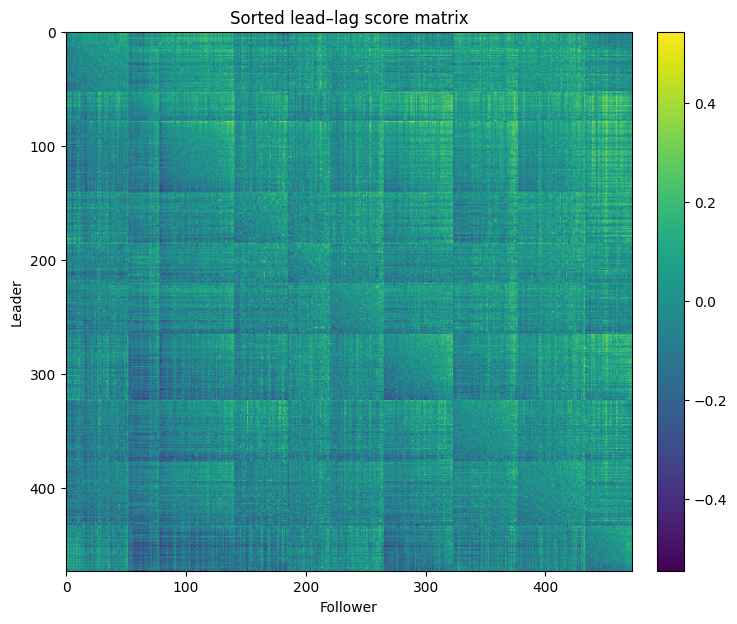

In [ ]:

# Heatmap of the sorted skew-symmetric lead-lag matrix
ordered_clusters = lead_scores.index.tolist()

order = []
for c in ordered_clusters:
    members = clusters[clusters == c].index.tolist()
    row_sums = (A.loc[members, members].sum(axis=1) - A.loc[members, members].sum(axis=0)).sort_values(ascending=False)
    order.extend(row_sums.index.tolist())

S_sorted = S.loc[order, order]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S_sorted.to_numpy(), aspect='auto')
ax.set_title('Sorted lead–lag score matrix')
ax.set_xlabel('Follower')
ax.set_ylabel('Leader')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Trading Strategy Construction

We build a simple signal based on delayed information diffusion.

---

### Intuition

If leader stocks move today:
- lagger stocks may follow tomorrow  

---

### Strategy

At each rebalance:

1. Identify:
   - top leader cluster  
   - bottom lagger cluster  

2. Observe leader return at time t  

3. Trade at time t+1:
   - long laggers if leaders went up  
   - short laggers if leaders went down  

4. Optionally hedge:
   - short leaders  

---

### Signal

$$
\text{signal} = \text{sign}(r_{\text{leader}})
$$

In [ ]:

def compute_cluster_returns(ret_slice: pd.DataFrame, clusters: pd.Series) -> pd.Series:
    aligned = ret_slice.reindex(columns=clusters.index)
    out = {}
    for c in sorted(clusters.unique()):
        cols = clusters.index[clusters == c]
        out[c] = aligned[cols].mean(axis=1).iloc[0]
    return pd.Series(out)


def rolling_lead_lag_backtest(ret: pd.DataFrame,
                              estimation_window: int = 252,
                              rebalance_freq: int = 5,
                              n_clusters: int = 10,
                              min_non_nan_frac: float = 0.90,
                              hedge_leader: bool = True):
    results = []

    dates = ret.index.tolist()

    for t in range(estimation_window + 1, len(dates) - 1, rebalance_freq):
        train_start = t - estimation_window
        train_end = t  # not inclusive
        signal_date = dates[t]
        trade_date = dates[t + 1]

        train_ret = ret.iloc[train_start:train_end]

        try:
            S = compute_lead_lag_matrix_lag1(train_ret, min_non_nan_frac=min_non_nan_frac)
            A = build_adjacency_from_S(S)
            clusters, eigvals_top, embed = hermitian_cluster(A, n_clusters=n_clusters, n_eigs=n_clusters)
            lead_scores = cluster_leadingness(A, clusters)

            leader_cluster = lead_scores.index[0]
            lagger_cluster = lead_scores.index[-1]

            # Use the leader cluster return on the signal date
            signal_ret = compute_cluster_returns(ret.loc[[signal_date], S.index], clusters)
            next_ret = compute_cluster_returns(ret.loc[[trade_date], S.index], clusters)

            leader_signal = signal_ret.loc[leader_cluster]

            if pd.isna(leader_signal):
                continue

            direction = np.sign(leader_signal)
            if direction == 0:
                continue

            lagger_trade_ret = direction * next_ret.loc[lagger_cluster]

            if hedge_leader:
                leader_hedge_ret = -direction * next_ret.loc[leader_cluster]
                strategy_ret = lagger_trade_ret + leader_hedge_ret
            else:
                leader_hedge_ret = np.nan
                strategy_ret = lagger_trade_ret

            results.append({
                'signal_date': signal_date,
                'trade_date': trade_date,
                'leader_cluster': int(leader_cluster),
                'lagger_cluster': int(lagger_cluster),
                'leader_signal': leader_signal,
                'direction': direction,
                'lagger_trade_ret': lagger_trade_ret,
                'leader_hedge_ret': leader_hedge_ret,
                'strategy_ret': strategy_ret,
                'n_stocks_used': int(len(S.index))
            })

        except Exception:
            continue

    if not results:
        return pd.DataFrame()

    bt = pd.DataFrame(results).set_index('trade_date').sort_index()
    bt['equity_curve'] = (1 + bt['strategy_ret'].fillna(0)).cumprod()
    return bt


## Backtesting Framework

We evaluate the strategy using a rolling window.

---

### Procedure

For each time step:

1. Use past 252 days to estimate:
   - lead–lag matrix  
   - clusters  

2. Generate signal at time t  

3. Apply trade at time t+1  

4. Record returns  

---

### Metrics

We compute:
- cumulative return  
- Sharpe ratio  
- equity curve  

---

### Notes

- Rebalancing frequency is configurable  
- Results are sensitive to window length  
- Stability improves with larger samples  

---

Backtest is intended to validate whether the signal has **predictive power**.

In [ ]:

bt = rolling_lead_lag_backtest(
    ret=ret,
    estimation_window=252,
    rebalance_freq=5,
    n_clusters=10,
    min_non_nan_frac=0.90,
    hedge_leader=True
)

print(bt.shape)
bt.head()


(251, 10)


,signal_date,leader_cluster,lagger_cluster,leader_signal,direction,lagger_trade_ret,leader_hedge_ret,strategy_ret,n_stocks_used,equity_curve
trade_date,,,,,,,,,,
2021-01-06,2021-01-05,1,0,0.009856,1.0,0.034459,-0.015664,0.018795,451,1.018795
2021-01-13,2021-01-12,1,4,0.016659,1.0,-0.013242,0.007195,-0.006048,451,1.012634
2021-01-21,2021-01-20,5,7,0.006201,1.0,-0.010983,0.006018,-0.004965,451,1.007606
2021-01-28,2021-01-27,8,2,-0.019673,-1.0,-0.001455,0.009281,0.007826,451,1.015492
2021-02-04,2021-02-03,2,4,0.011694,1.0,0.010680,-0.015536,-0.004855,451,1.010562


In [ ]:

if not bt.empty:
    ann_factor = 252 / 5  # because rebalance_freq=5
    mean_ret = bt['strategy_ret'].mean()
    vol_ret = bt['strategy_ret'].std()

    sharpe = np.nan if vol_ret == 0 else np.sqrt(ann_factor) * mean_ret / vol_ret
    cumret = bt['equity_curve'].iloc[-1] - 1

    print(f'Cumulative return: {cumret:.2%}')
    print(f'Annualized Sharpe (rough): {sharpe:.3f}')
    print(f'Average stocks used per rebalance: {bt["n_stocks_used"].mean():.1f}')


Cumulative return: 29.99%
Annualized Sharpe (rough): 0.470
Average stocks used per rebalance: 481.1


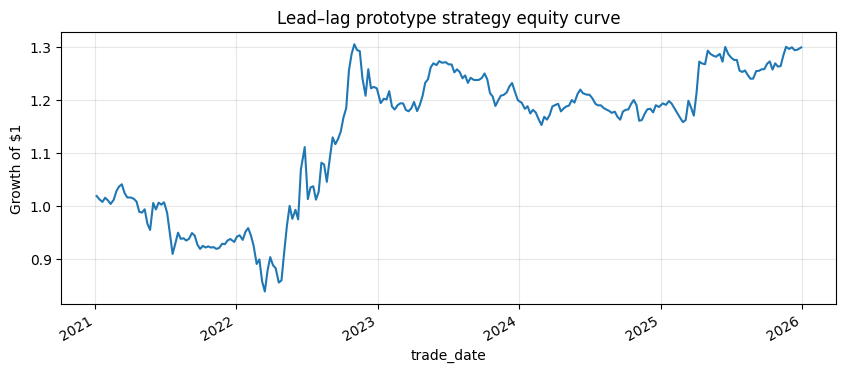

In [ ]:

if not bt.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    bt['equity_curve'].plot(ax=ax)
    ax.set_title('Lead–lag prototype strategy equity curve')
    ax.set_ylabel('Growth of $1')
    ax.grid(True, alpha=0.3)
    plt.show()
